In [ ]:
import os, random, time, json
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, models, transforms
from PIL import Image
from sklearn.model_selection import train_test_split

SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [ ]:
root = "./data"
trainval = datasets.OxfordIIITPet(root, split="trainval", target_types="category", download=True)
testset  = datasets.OxfordIIITPet(root, split="test",     target_types="category", download=True)

all_paths  = list(trainval._images) + list(testset._images)
all_labels = list(trainval._labels) + list(testset._labels)
class_names_all = trainval.classes

CHOSEN = ["Bengal", "Birman", "Persian", "Ragdoll", "Siamese",
          "Basset Hound", "Beagle", "Pug", "Samoyed", "Shiba Inu"]
chosen_ids = [class_names_all.index(c) for c in CHOSEN]
id_map = {old: new for new, old in enumerate(chosen_ids)}

paths, labels = [], []
for p, l in zip(all_paths, all_labels):
    if l in id_map:
        paths.append(p)
        labels.append(id_map[l])

p_train, p_tmp, y_train, y_tmp = train_test_split(
    paths, labels, test_size=0.30, stratify=labels, random_state=SEED)
p_val, p_test, y_val, y_test = train_test_split(
    p_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=SEED)

print(f"Total: {len(paths)} | train: {len(p_train)} | val: {len(p_val)} | test: {len(p_test)}")
print("Per class (train):", np.bincount(y_train))

100%|██████████| 792M/792M [00:30<00:00, 25.9MB/s]
100%|██████████| 19.2M/19.2M [00:02<00:00, 8.71MB/s]


Total: 1999 | train: 1399 | val: 300 | test: 300
Per class (train): [140 140 140 140 139 140 140 140 140 140]


In [ ]:
from google.colab import drive
drive.mount("/content/drive")
SAVE_DIR = "/content/drive/MyDrive/Tugas05"
os.makedirs(SAVE_DIR, exist_ok=True)

NUM_CLASSES = 10
BATCH_SIZE = 32
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

eval_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

aug_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

class PetSubset(Dataset):
    def __init__(self, paths, labels, transform):
        self.paths = paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, i):
        img = Image.open(self.paths[i]).convert("RGB")
        return self.transform(img), self.labels[i]

def make_loaders(augment):
    train_tf = aug_tf if augment else eval_tf
    g = torch.Generator().manual_seed(SEED)   # makes sure that shuffle order is able to be reproduced
    train_dl = DataLoader(PetSubset(p_train, y_train, train_tf), batch_size=BATCH_SIZE,
                          shuffle=True, num_workers=2, generator=g)
    val_dl   = DataLoader(PetSubset(p_val, y_val, eval_tf), batch_size=BATCH_SIZE, num_workers=2)
    test_dl  = DataLoader(PetSubset(p_test, y_test, eval_tf), batch_size=BATCH_SIZE, num_workers=2)
    return train_dl, val_dl, test_dl

Mounted at /content/drive


In [ ]:
def freeze_bn_stats(model):
    for m in model.modules():
        if isinstance(m, nn.BatchNorm2d) and not m.weight.requires_grad:
            m.eval()

def build_model(mode):
    if mode == "effnet_feature":   # for b5
        model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
        for p in model.parameters():
            p.requires_grad = False
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, NUM_CLASSES)
        groups = [{"params": model.classifier.parameters(), "lr": 1e-3}]
        return model.to(device), groups

    weights = None if mode == "scratch" else models.ResNet18_Weights.IMAGENET1K_V1
    model = models.resnet18(weights=weights)
    model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)

    if mode == "scratch":       # for b1
        groups = [{"params": model.parameters(), "lr": 1e-3}]

    elif mode == "feature":     # for b2
        for p in model.parameters():
            p.requires_grad = False
        for p in model.fc.parameters():
            p.requires_grad = True
        groups = [{"params": model.fc.parameters(), "lr": 1e-3}]

    elif mode == "finetune":  # for b3 and b4
        for p in model.parameters():
            p.requires_grad = False
        for p in list(model.layer4.parameters()) + list(model.fc.parameters()):
            p.requires_grad = True
        groups = [{"params": model.layer4.parameters(), "lr": 1e-4},
                  {"params": model.fc.parameters(),     "lr": 1e-3}]

    return model.to(device), groups

In [ ]:
import copy
import pandas as pd
from sklearn.metrics import f1_score

RESULTS_CSV = f"{SAVE_DIR}/results.csv"
HISTORY_CSV = f"{SAVE_DIR}/history.csv"

results     = pd.read_csv(RESULTS_CSV).to_dict("records") if os.path.exists(RESULTS_CSV) else []
all_history = pd.read_csv(HISTORY_CSV).to_dict("records") if os.path.exists(HISTORY_CSV) else []

def save_logs():
    pd.DataFrame(results).to_csv(RESULTS_CSV, index=False)
    pd.DataFrame(all_history).to_csv(HISTORY_CSV, index=False)
    pd.DataFrame(results).to_json(f"{SAVE_DIR}/results.json", orient="records", indent=2)

def run_epoch(model, loader, criterion, optimizer=None):
    training = optimizer is not None
    model.train() if training else model.eval()
    if training:
        freeze_bn_stats(model)
    total_loss, correct, n = 0.0, 0, 0
    with torch.set_grad_enabled(training):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss = criterion(out, y)
            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * x.size(0)
            correct += (out.argmax(1) == y).sum().item()
            n += x.size(0)
    return total_loss / n, correct / n

@torch.no_grad()
def predict(model, loader):
    model.eval()
    probs, ys = [], []
    for x, y in loader:
        probs.append(torch.softmax(model(x.to(device)), dim=1).cpu())
        ys.append(y)
    return torch.cat(probs), torch.cat(ys)

def run_experiment(name, mode, augment, max_epochs=30, patience=5):
    global results, all_history
    set_seed()
    train_dl, val_dl, test_dl = make_loaders(augment)
    model, groups = build_model(mode)
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    lrs = [g["lr"] for g in groups]
    print(f"{name} | trainable params: {trainable:,} | lr per group: {lrs}")

    optimizer = torch.optim.AdamW(groups, weight_decay=1e-2)
    criterion = nn.CrossEntropyLoss()
    history, best_loss, best_epoch, bad = [], float("inf"), 0, 0
    start = time.time()

    for epoch in range(1, max_epochs + 1):
        tr_loss, tr_acc = run_epoch(model, train_dl, criterion, optimizer)
        va_loss, va_acc = run_epoch(model, val_dl, criterion)
        history.append(dict(experiment=name, epoch=epoch, train_loss=tr_loss, train_acc=tr_acc,
                            val_loss=va_loss, val_acc=va_acc))
        print(f"  epoch {epoch:2d} | train loss {tr_loss:.3f} acc {tr_acc:.3f} | val loss {va_loss:.3f} acc {va_acc:.3f}")

        if va_loss < best_loss:
            best_loss, best_epoch, bad = va_loss, epoch, 0
            best_state = copy.deepcopy(model.state_dict())
        else:
            bad += 1
            if bad >= patience:
                print(f"  early stopping (no val loss improvement for {patience} epochs)")
                break

    train_time = time.time() - start
    model.load_state_dict(best_state) # use the best epoch

    probs, y = predict(model, test_dl)
    preds = probs.argmax(1)
    best = history[best_epoch - 1]
    row = dict(experiment=name, mode=mode, augment=augment, trainable_params=trainable,
               lr_per_group=str(lrs), best_epoch=best_epoch, epochs_run=len(history),
               train_time_s=round(train_time, 1), train_acc=best["train_acc"],
               val_acc=best["val_acc"], test_acc=(preds == y).float().mean().item(),
               test_macro_f1=f1_score(y, preds, average="macro"))
    results = [r for r in results if r["experiment"] != name] + [row]
    all_history = [h for h in all_history if h["experiment"] != name] + history
    save_logs()
    torch.save(model.state_dict(), f"{SAVE_DIR}/{name}.pt")
    print(f"  done in {train_time:.0f}s | val acc {row['val_acc']:.3f} | test macro F1 {row['test_macro_f1']:.3f}")
    return model, probs, y

In [ ]:
model_b1, probs_b1, _ = run_experiment("B1_scratch", "scratch", augment=True)

B1_scratch | trainable params: 11,181,642 | lr per group: [0.001]
  epoch  1 | train loss 2.326 acc 0.162 | val loss 2.041 acc 0.253
  epoch  2 | train loss 1.986 acc 0.247 | val loss 2.411 acc 0.257
  epoch  3 | train loss 1.894 acc 0.308 | val loss 1.852 acc 0.323
  epoch  4 | train loss 1.869 acc 0.296 | val loss 1.992 acc 0.310
  epoch  5 | train loss 1.710 acc 0.385 | val loss 2.034 acc 0.310
  epoch  6 | train loss 1.604 acc 0.423 | val loss 1.714 acc 0.370
  epoch  7 | train loss 1.527 acc 0.445 | val loss 1.982 acc 0.303
  epoch  8 | train loss 1.460 acc 0.473 | val loss 1.599 acc 0.407
  epoch  9 | train loss 1.391 acc 0.499 | val loss 2.261 acc 0.377
  epoch 10 | train loss 1.282 acc 0.532 | val loss 1.680 acc 0.477
  epoch 11 | train loss 1.254 acc 0.535 | val loss 2.265 acc 0.383
  epoch 12 | train loss 1.217 acc 0.568 | val loss 2.568 acc 0.367
  epoch 13 | train loss 1.121 acc 0.594 | val loss 1.523 acc 0.463
  epoch 14 | train loss 1.020 acc 0.627 | val loss 1.637 acc 0.

In [ ]:
model_b2, probs_b2, y_test_t = run_experiment("B2_feature_extraction", "feature", augment=True)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 189MB/s]


B2_feature_extraction | trainable params: 5,130 | lr per group: [0.001]
  epoch  1 | train loss 1.206 acc 0.646 | val loss 0.588 acc 0.877
  epoch  2 | train loss 0.481 acc 0.884 | val loss 0.375 acc 0.920
  epoch  3 | train loss 0.351 acc 0.915 | val loss 0.294 acc 0.917
  epoch  4 | train loss 0.293 acc 0.917 | val loss 0.276 acc 0.920
  epoch  5 | train loss 0.253 acc 0.931 | val loss 0.234 acc 0.927
  epoch  6 | train loss 0.236 acc 0.928 | val loss 0.264 acc 0.900
  epoch  7 | train loss 0.215 acc 0.939 | val loss 0.218 acc 0.927
  epoch  8 | train loss 0.205 acc 0.947 | val loss 0.195 acc 0.940
  epoch  9 | train loss 0.180 acc 0.951 | val loss 0.212 acc 0.910
  epoch 10 | train loss 0.189 acc 0.945 | val loss 0.184 acc 0.937
  epoch 11 | train loss 0.184 acc 0.945 | val loss 0.183 acc 0.943
  epoch 12 | train loss 0.177 acc 0.943 | val loss 0.182 acc 0.930
  epoch 13 | train loss 0.164 acc 0.951 | val loss 0.183 acc 0.933
  epoch 14 | train loss 0.160 acc 0.951 | val loss 0.176 

In [ ]:
model_b3, probs_b3, _ = run_experiment("B3_finetune", "finetune", augment=True)

B3_finetune | trainable params: 8,398,858 | lr per group: [0.0001, 0.001]
  epoch  1 | train loss 0.722 acc 0.777 | val loss 0.233 acc 0.913
  epoch  2 | train loss 0.216 acc 0.931 | val loss 0.181 acc 0.937
  epoch  3 | train loss 0.131 acc 0.966 | val loss 0.166 acc 0.937
  epoch  4 | train loss 0.079 acc 0.981 | val loss 0.189 acc 0.937
  epoch  5 | train loss 0.066 acc 0.981 | val loss 0.173 acc 0.927
  epoch  6 | train loss 0.043 acc 0.989 | val loss 0.211 acc 0.920
  epoch  7 | train loss 0.034 acc 0.991 | val loss 0.185 acc 0.917
  epoch  8 | train loss 0.022 acc 0.996 | val loss 0.196 acc 0.923
  early stopping (no val loss improvement for 5 epochs)
  done in 119s | val acc 0.937 | test macro F1 0.926


In [ ]:
model_b4, probs_b4, _ = run_experiment("B4_finetune_no_aug", "finetune", augment=False)

B4_finetune_no_aug | trainable params: 8,398,858 | lr per group: [0.0001, 0.001]
  epoch  1 | train loss 0.653 acc 0.806 | val loss 0.219 acc 0.920
  epoch  2 | train loss 0.106 acc 0.979 | val loss 0.169 acc 0.940
  epoch  3 | train loss 0.032 acc 0.999 | val loss 0.168 acc 0.930
  epoch  4 | train loss 0.016 acc 0.999 | val loss 0.164 acc 0.953
  epoch  5 | train loss 0.009 acc 0.999 | val loss 0.159 acc 0.953
  epoch  6 | train loss 0.006 acc 1.000 | val loss 0.166 acc 0.947
  epoch  7 | train loss 0.003 acc 1.000 | val loss 0.158 acc 0.947
  epoch  8 | train loss 0.003 acc 1.000 | val loss 0.146 acc 0.950
  epoch  9 | train loss 0.003 acc 1.000 | val loss 0.150 acc 0.947
  epoch 10 | train loss 0.002 acc 1.000 | val loss 0.159 acc 0.940
  epoch 11 | train loss 0.002 acc 1.000 | val loss 0.167 acc 0.937
  epoch 12 | train loss 0.002 acc 1.000 | val loss 0.158 acc 0.943
  epoch 13 | train loss 0.002 acc 1.000 | val loss 0.154 acc 0.953
  early stopping (no val loss improvement for 5 

In [ ]:
model_b5, probs_b5, _ = run_experiment("B5_effnet_b0_feature", "effnet_feature", augment=True)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 138MB/s]


B5_effnet_b0_feature | trainable params: 12,810 | lr per group: [0.001]
  epoch  1 | train loss 1.025 acc 0.778 | val loss 0.401 acc 0.917
  epoch  2 | train loss 0.346 acc 0.911 | val loss 0.263 acc 0.937
  epoch  3 | train loss 0.249 acc 0.926 | val loss 0.217 acc 0.943
  epoch  4 | train loss 0.207 acc 0.948 | val loss 0.189 acc 0.953
  epoch  5 | train loss 0.177 acc 0.957 | val loss 0.168 acc 0.957
  epoch  6 | train loss 0.166 acc 0.953 | val loss 0.153 acc 0.967
  epoch  7 | train loss 0.148 acc 0.961 | val loss 0.148 acc 0.960
  epoch  8 | train loss 0.145 acc 0.959 | val loss 0.140 acc 0.960
  epoch  9 | train loss 0.131 acc 0.956 | val loss 0.135 acc 0.963
  epoch 10 | train loss 0.136 acc 0.959 | val loss 0.136 acc 0.957
  epoch 11 | train loss 0.114 acc 0.973 | val loss 0.125 acc 0.963
  epoch 12 | train loss 0.110 acc 0.970 | val loss 0.123 acc 0.970
  epoch 13 | train loss 0.103 acc 0.973 | val loss 0.120 acc 0.960
  epoch 14 | train loss 0.104 acc 0.965 | val loss 0.120 

In [ ]:
summary = pd.DataFrame(results)
summary["gap"] = summary["train_acc"] - summary["val_acc"]   # overfitting indicator
cols = ["experiment", "trainable_params", "lr_per_group", "best_epoch", "epochs_run",
        "train_time_s", "train_acc", "val_acc", "test_macro_f1", "gap"]
display(summary[cols].round(3))

# Total params (for the B5 efficiency comparison)
for mode in ["feature", "effnet_feature"]:
    m, _ = build_model(mode)
    print(f"{mode}: total params {sum(p.numel() for p in m.parameters()):,}")

,experiment,trainable_params,lr_per_group,best_epoch,epochs_run,train_time_s,train_acc,val_acc,test_macro_f1,gap
0,B2_feature_extraction,5130,[0.001],18,23,342.0,0.947,0.937,0.941,0.010
1,B3_finetune,8398858,"[0.0001, 0.001]",3,8,119.3,0.966,0.937,0.926,0.029
2,B1_scratch,11181642,[0.001],21,26,399.5,0.731,0.587,0.550,0.144
3,B4_finetune_no_aug,8398858,"[0.0001, 0.001]",8,13,125.5,1.000,0.950,0.927,0.050
4,B5_effnet_b0_feature,12810,[0.001],29,30,443.7,0.975,0.973,0.970,0.002


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 153MB/s]


feature: total params 11,181,642
effnet_feature: total params 4,020,358


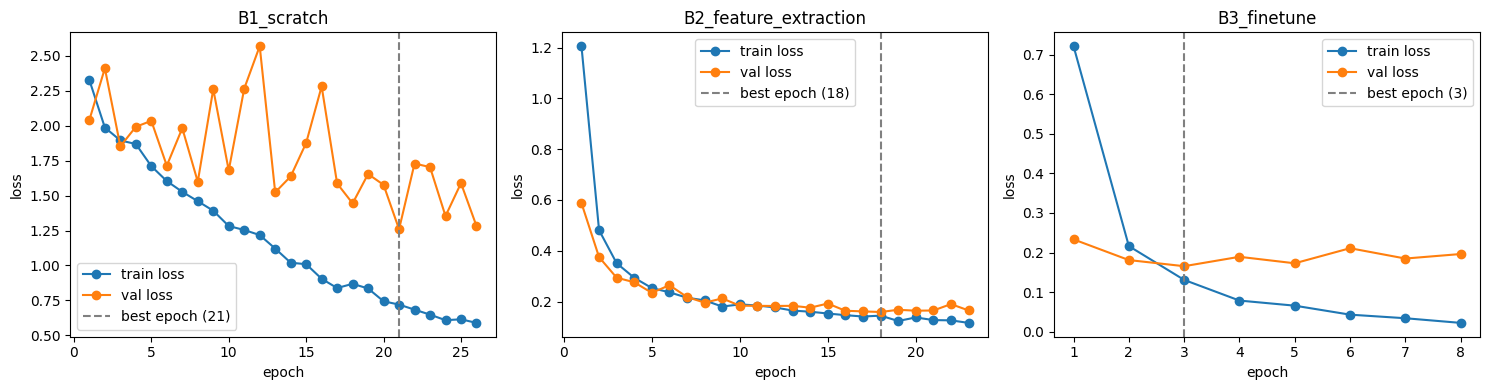

In [ ]:
import matplotlib.pyplot as plt

hist = pd.DataFrame(all_history)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, name in zip(axes, ["B1_scratch", "B2_feature_extraction", "B3_finetune"]):
    h = hist[hist["experiment"] == name]
    ax.plot(h["epoch"], h["train_loss"], marker="o", label="train loss")
    ax.plot(h["epoch"], h["val_loss"], marker="o", label="val loss")
    best = h.loc[h["val_loss"].idxmin(), "epoch"]
    ax.axvline(best, color="gray", linestyle="--", label=f"best epoch ({best})")
    ax.set_title(name)
    ax.set_xlabel("epoch")
    ax.set_ylabel("loss")
    ax.legend()
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/loss_curves.png", dpi=150)
plt.show()

9 wrong out of 300 test images


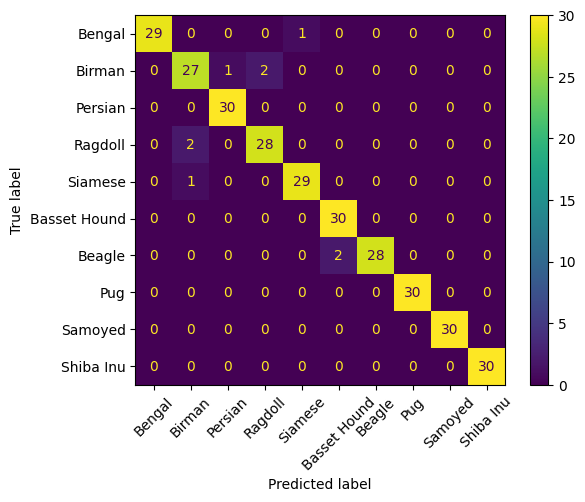

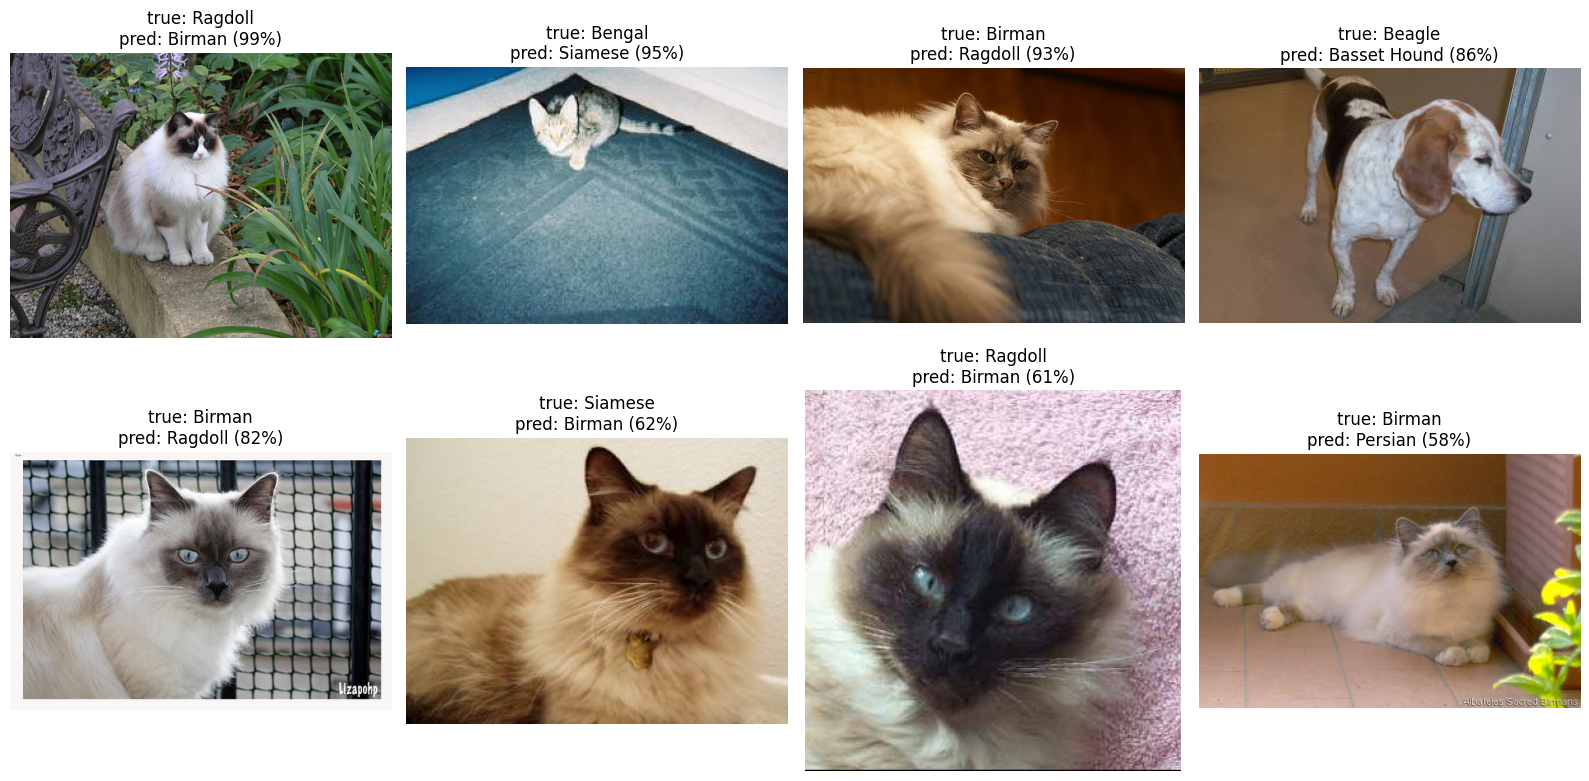

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

best_model, _ = build_model("effnet_feature")
best_model.load_state_dict(torch.load(f"{SAVE_DIR}/B5_effnet_b0_feature.pt"))
_, _, test_dl = make_loaders(augment=False)

probs, y = predict(best_model, test_dl)
conf, preds = probs.max(1)
wrong = (preds != y).nonzero().flatten().tolist()
print(f"{len(wrong)} wrong out of {len(y)} test images")

# Which breeds get confused with which
ConfusionMatrixDisplay.from_predictions(y, preds, display_labels=CHOSEN, xticks_rotation=45)
plt.savefig(f"{SAVE_DIR}/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

# The 8 most confident mistakes (the most "interesting" failures)
wrong = sorted(wrong, key=lambda i: -conf[i].item())[:8]
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, i in zip(axes.flatten(), wrong):
    ax.imshow(Image.open(p_test[i]).convert("RGB"))
    ax.set_title(f"true: {CHOSEN[int(y[i])]}\npred: {CHOSEN[int(preds[i])]} ({conf[i]:.0%})")
    ax.axis("off")
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/failures.png", dpi=150)
plt.show()

# Raw log of the failures (the report numbers must be backed by logs)
pd.DataFrame([{"file": os.path.basename(p_test[i]), "true": CHOSEN[int(y[i])],
               "pred": CHOSEN[int(preds[i])], "confidence": round(conf[i].item(), 3)}
              for i in wrong]).to_csv(f"{SAVE_DIR}/failures.csv", index=False)

In [ ]:
import sklearn, matplotlib, PIL
pkgs = {"torch": torch, "torchvision": __import__("torchvision"), "scikit-learn": sklearn,
        "pandas": pd, "numpy": np, "matplotlib": matplotlib, "pillow": PIL}
reqs = "\n".join(f"{name}=={mod.__version__.split('+')[0]}" for name, mod in pkgs.items())
with open(f"{SAVE_DIR}/requirements.txt", "w") as f:
    f.write(reqs + "\n")
print(reqs)

torch==2.11.0
torchvision==0.26.0
scikit-learn==1.6.1
pandas==2.2.3
numpy==2.1.3
matplotlib==3.10.0
pillow==11.3.0
